# P2 sistemático y edge P0–P4: evaluación completa

**Qué es este cuaderno:** el registro reproducible de todo lo analizado entre el 2026-09-21 y el
2026-09-23 sobre P2 y sobre el edge completo. Cada número se recalcula acá, desde las bases de datos
(en **solo lectura**) y desde las velas exportadas de MT5. Nada está copiado a mano.

**Para quién:** para decidir si conviene automatizar P2, con qué modelo, y qué esperar de esa decisión.

**Cómo leerlo:** la primera sección es el resumen para decidir. El resto es la evidencia, en el orden
en que conviene leerla. La sección 12 compara las opciones.

> **Versión 2, 2026-09-23.** La versión anterior de este cuaderno tenía dos sesgos que inflaban los
> resultados: medía desde la hora de la **entrada** en vez de la hora del **análisis**, y dejaba entrar
> la **vela todavía en formación** con su cierre final. Los dos se corrigieron en el código, con tests, y
> todo el cuaderno se recalculó. §1.3 muestra cuánto cambió cada número. Si volvés a ejecutarlo con más
> análisis, las tablas se actualizan solas; el texto de las conclusiones no, así que contrastalo con las celdas.

## 0. Resumen para decidir

Todo medido desde el **momento del análisis** y solo con **velas ya cerradas** (§1.3).

| Pregunta | Respuesta corta | Dónde está la evidencia |
|---|---|---|
| ¿El edge completo (P0–P4) acierta la dirección más que el azar? | **No se puede afirmar.** Medido desde el análisis, 36 de 60 (60%), p=0.47 tras la corrección de Holm. Medido desde la **entrada**, como decía el pre-registro, 69% y p=0.013. La diferencia puede ser el valor de esperar confirmación antes de entrar, o un sesgo de medir más tarde: con estos datos no se separan. | §3 |
| ¿Le gana a una regla simple de tendencia? | **No.** A la tendencia diaria le va ganando (19 vs 11 en los desacuerdos, p=0.20), pero **la tendencia de 4H acierta un poco más** que el edge en los mismos análisis (65% vs 60%). | §3 |
| ¿P2 cambia alguna decisión dentro del edge? | **No.** Ningún modelo invirtió una sola dirección: P2 pesa 0.075 por punto. | §5 |
| ¿El P2 calculado es mejor que tu P2 manual? | **No se distingue.** Tu P2 57%, F 60%, A 52%. Ninguno se separa del azar. | §6 |
| ¿Qué modelo es mejor? | **D y F son los mejores en el papel** (66% y 60%, neto +12 y +9), pero **ninguno sobrevive** a la corrección por haber elegido el mejor de 7 (p=0.105). | §6, §8.1 |
| ¿Qué hace mejor a D y F? | Cargar peso en **1H** (15 análisis mejoran contra 6 empeoran, p=0.078): en el borde, no concluyente. | §7, §8.4 |
| ¿Es sobreajuste? | **No hay nada entrenado, pero tampoco hay señal que proteger.** El mejor de 7 variantes no le gana a lo que da el azar. | §8 |
| ¿El indicador funciona por sí solo? | **No.** F acierta 57% en tus momentos y 54% en momentos al azar: la diferencia es ruido (p=0.76). | §8.7 |
| ¿Sirve el consenso vos + modelo? | **Es lo mejor que hay, pero no alcanza a ser concluyente:** 14 de 20 (70%) con D o con F, p=0.115. Con A, 61%. | §9 |
| ¿Conviene cambiar los pesos P0–P4? | **No.** Nada mejoró fuera de muestra. | §3 |
| ¿El sistema gana plata? | **No se puede afirmar.** +0.17R por trade, pero el intervalo incluye el cero. | §3 |

**Veredicto:** con los sesgos corregidos, **ninguna versión de P2, ni el consenso, tiene evidencia de
acertar más que el azar** con 89 análisis. La opción 4 sigue siendo razonable **como forma barata de
medir**, no porque esté probado que funciona: P2 no cambia tus trades, y el test con análisis nuevos es
ahora la evidencia principal. **El modelo activo pasa de F a D**: con los datos corregidos, D tiene el mejor
neto y, a diferencia de F, se definió antes de ver los datos. Ver §12.

### Glosario mínimo

- **Edge / `calc_edge`:** tu índice direccional. Suma ponderada de P0–P4 dividida por 2. Si pasa de
  +0.26 es Bullish, si baja de −0.26 es Bearish, y en el medio es **Choppy** (no apuesta).
- **Ancla:** el momento desde el que se mide. Acá es la **hora del análisis**, estimada como
  `created_at` − 15 minutos: `created_at` se guarda al apretar "Confirm & Save", después de cargar P2.
- **Ground truth ("la verdad"):** qué nivel tocó primero el precio después del ancla. El
  `edge_validation_price` significa que la tesis se cumplió; el `structural_invalidation`, que se rompió.
  Se mide sobre velas reales de 1H.
- **Vela cerrada:** una vela que ya terminó en el ancla. MT5 nombra cada vela por su hora de apertura:
  a las 06:15, la vela de 1H "de las 06:00" todavía está abierta y la última cerrada es la de las 05:00.
- **Apuesta / abstención:** un predictor "apuesta" cuando da una dirección, y "se abstiene" cuando
  dice 0 o Choppy. Las abstenciones no cuentan como acierto ni como fallo.
- **Neto:** aciertos menos fallos. Premia acertar y castiga fallar; abstenerse suma 0.
- **p (p-valor):** qué tan seguido saldría un resultado así **por pura suerte**. Menos de 0.05 se
  considera "difícil de explicar por suerte".
- **Holm:** corrección que sube la vara cuando se hacen varias preguntas a la vez.
- **IC95:** rango donde probablemente está el valor real. Si dos rangos se superponen mucho, la
  diferencia puede ser ruido.
- **Pre-registrado:** la regla de decisión se fijó **antes** de ver los resultados. Es la
  evidencia más confiable. Lo **exploratorio** se descubrió mirando los datos y hay que reconfirmarlo.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "jupyter" else os.getcwd()
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import sqlite3
from collections import Counter
from dataclasses import replace
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from dotenv import load_dotenv

from cli.main import determine_market_bias
from core.math_engine import calculate_edge_score
from core.stats_tests import (binomial_test_two_sided, wilson_interval, net_score,
                              permutation_max_net_test)
from tools.p2_backtest import (MODELS, MODELS_BY_NAME, MODEL_A, MODEL_C, MODEL_D, MODEL_F,
                               ALL_TIMEFRAMES, assemble_p2_systematic_rows, calibrate_clock_offset,
                               compute_score_p2_sistematico, rescale_p2_sistematico,
                               bias_to_direction, load_ohlc_provider_from_csv, open_readonly_session,
                               ANCHOR_MODE_ANALYSIS, ANCHOR_MODE_EXECUTION, CsvOHLCProvider)
from core.p2_ground_truth import first_touch_direction, infer_thesis_direction
from tools import edge_evaluation as ev

load_dotenv(os.path.join(ROOT, ".env"))
MT5 = os.path.dirname(os.getenv("P2_SYSTEMATIC_OHLC_DIR").rstrip("/"))   # .../MT5Exports
CUENTAS = {  # nombre: (DB de la cuenta, carpeta de velas en MT5Exports)
    "XAUUSD": (".data/flight_account_001_xauusd.db", "XAUUSD"),
    "BTCUSD": (".data/flight_account_002_btcusdtp.db", "BTCUSD"),
    "US100":  (".data/flight_account_003_us100.db", "USTEC"),   # en MT5 se llama USTEC
}
SEED = 20260923

# Paleta de referencia del skill de visualización (validada: 2 series + colores de estado)
INK, INK2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, GOOD, BAD = "#2a78d6", "#eb6834", "#0ca30c", "#d03b3b"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "font.family": "sans-serif", "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "axes.axisbelow": True,
})
pd.set_option("display.max_colwidth", 200)
print("MT5Exports:", MT5)

MT5Exports: /mnt/c/Users/jcifu/MT5Exports


## 1. Datos y controles de calidad

Antes de medir nada hubo que corregir **seis problemas**. Todos se encontraron durante este trabajo, y
cualquiera de ellos habría contaminado los resultados. Los dos últimos se encontraron después de la
primera versión de este cuaderno y son los que más cambiaron las conclusiones (§1.3).

| Problema | Qué pasaba | Cómo se corrigió |
|---|---|---|
| **Reloj de las velas corrido +3h** | MT5 entrega la hora del **servidor** (UTC+3) y el exportador la trataba como UTC. "Después del análisis" arrancaba 3 horas antes. | Exportador corregido, y un control automático que aborta si el reloj no cuadra (§1.2). |
| **Historia insuficiente** | La ventana pedida a MT5 no cubría los fines de semana: 1D traía 794 velas, 30M 782. | Margen ×2 más un colchón de 7 días. |
| **Etiquetas de exclusión cruzadas** | 25 de 26 análisis "sin filas tácticas" sí tenían filas, con la hora vacía. | Etiquetas corregidas. No cambia ningún resultado. |
| **DB de US100 sin migrar** | Le faltaban 4 columnas nuevas y la lectura fallaba. | Se leen solo las columnas necesarias. No se tocó la DB. |
| **Ancla tardía** | Se medía desde la **primera entrada**, una mediana de 30 min después del análisis, cuando ya habías decidido P2. En 25 casos era la hora de una orden que nunca se llenó. | Se mide desde el análisis: `created_at` − 15 min, con el precio de la última vela cerrada. |
| **Vela en formación (look-ahead)** | Entraba la vela que abrió antes del ancla **con su cierre final**. En 1W, un análisis del miércoles veía el cierre del viernes. | Solo velas cerradas (`closed_bars`), con tests (`tests/test_p2_closed_bars.py`). |

Además se validó `mark_price`, el precio que anotás al terminar un análisis. Ya no se usa como precio de
partida, pero sirve para verificar el reloj (§1.1).

In [2]:
# Carga de datos: una fila por análisis con niveles, medido en el momento del análisis
# (created_at − 15 min) y solo con velas ya cerradas en ese momento (§1.3).
def cargar(nombre, anchor_mode=ANCHOR_MODE_ANALYSIS, proveedor=CsvOHLCProvider, **kw):
    db, carpeta = CUENTAS[nombre]
    prov = proveedor(os.path.join(MT5, carpeta))
    rows, excl = assemble_p2_systematic_rows(open_readonly_session(db), prov, include_no_execution=True,
                                             anchor_mode=anchor_mode, **kw)
    return prov, rows, excl

DATA = {n: cargar(n) for n in CUENTAS}
resumen = []
for n, (prov, rows, excl) in DATA.items():
    resumen.append({
        "Cuenta": n,
        "Análisis medidos": len(rows),
        "Resueltos": sum(not r.ground_truth_incompleto for r in rows),
        "Excluidos": len(excl),
        "Motivos de exclusión": ", ".join(f"{k} ({v})" for k, v in Counter(e.reason for e in excl).most_common()),
    })
pd.DataFrame(resumen).set_index("Cuenta")

,Análisis medidos,Resueltos,Excluidos,Motivos de exclusión
Cuenta,,,,
XAUUSD,69,67,12,"backdated_no_analysis_time (7), missing_edge_validation_price_or_structural_invalidation (5)"
BTCUSD,23,22,1,missing_edge_validation_price_or_structural_invalidation (1)
US100,8,7,0,


### 1.1 ¿Es confiable `mark_price`?

Si `mark_price` es el precio real del momento del análisis, tiene que caer **dentro de la vela de 15
minutos** de ese momento. Lo mismo vale, con más razón, para una orden llenada: tiene que estar dentro
del rango de su vela.

In [3]:
from sqlalchemy import select
from tools.database import TacticalAudit, UnifiedDepartment

def puntos_referencia(db):
    s = open_readonly_session(db)
    fills = s.execute(select(TacticalAudit.entry_time, TacticalAudit.entry_price).where(
        TacticalAudit.order_filled == True, TacticalAudit.entry_time.isnot(None),
        TacticalAudit.entry_price > 0)).all()
    marks = s.execute(select(UnifiedDepartment.created_at, UnifiedDepartment.mark_price).where(
        UnifiedDepartment.mark_price > 0, UnifiedDepartment.is_backdated.isnot(True))).all()
    return fills, marks

def dentro_de_su_vela(prov, pts, desplazamiento_h):
    ok = tot = 0
    for t, p in pts:
        bar = prov.bar_containing("15M", t + pd.Timedelta(hours=desplazamiento_h))
        if bar:
            tot += 1; ok += bar[1] <= float(p) <= bar[0]
    return f"{ok}/{tot} ({ok/tot*100:.0f}%)" if tot else "—"

filas = []
for n, (prov, _, _) in DATA.items():
    fills, marks = puntos_referencia(CUENTAS[n][0])
    for etiqueta, pts in (("órdenes llenadas", fills), ("mark_price", marks)):
        filas.append({"Cuenta": n, "Precio": etiqueta, "n": len(pts),
                      "Reloj sin desplazar (correcto)": dentro_de_su_vela(prov, pts, 0),
                      "Reloj corrido +3h (el bug)": dentro_de_su_vela(prov, pts, 3)})
pd.DataFrame(filas).set_index(["Cuenta", "Precio"])

n Reloj sin desplazar (correcto)  \
Cuenta Precio                                                
XAUUSD órdenes llenadas  35                    26/34 (76%)   
       mark_price        70                    55/70 (79%)   
BTCUSD órdenes llenadas   4                      2/4 (50%)   
       mark_price        15                    13/15 (87%)   
US100  órdenes llenadas   1                     1/1 (100%)   
       mark_price         8                      7/8 (88%)   

                        Reloj corrido +3h (el bug)  
Cuenta Precio                                       
XAUUSD órdenes llenadas                 4/31 (13%)  
       mark_price                       7/70 (10%)  
BTCUSD órdenes llenadas                  1/4 (25%)  
       mark_price                        1/15 (7%)  
US100  órdenes llenadas                   0/1 (0%)  
       mark_price                        1/8 (12%)

**Lectura:** con el reloj correcto, la gran mayoría de las órdenes y de los `mark_price` cae dentro de
su vela, y con el reloj corrido 3 horas casi ninguno. Eso confirma que **el reloj ahora está bien** y
que **`mark_price` es el precio real del momento**. Las pocas que no cuadran son probablemente horas
anotadas a mano con unos minutos de diferencia.

### 1.2 Control automático del reloj y profundidad de la historia

`calibrate_clock_offset()` hace la prueba anterior en cada corrida y **se niega a generar resultados**
si el reloj no cuadra. Además, los modelos P2 exigen **800 velas previas** en cada temporalidad.

In [4]:
filas = []
primer = {n: min(r.timestamp_entry for r in rows) for n, (_, rows, _) in DATA.items()}
for n, (prov, _, _) in DATA.items():
    c = calibrate_clock_offset(open_readonly_session(CUENTAS[n][0]), prov)
    fila = {"Cuenta": n, "Reloj": c.describe().split(":")[0]}
    for tf in ALL_TIMEFRAMES:
        df = prov._load_tf(tf)
        k = int((df["time"] < primer[n]).sum())
        fila[tf] = f"{k}" + ("" if k >= 800 else " ✗")
    filas.append(fila)
print("Velas disponibles ANTES del primer análisis de cada cuenta (mínimo 800; ✗ = no alcanza):")
pd.DataFrame(filas).set_index("Cuenta")

Velas disponibles ANTES del primer análisis de cada cuenta (mínimo 800; ✗ = no alcanza):


,Reloj,1W,1D,12H,4H,1H,30M,15M
Cuenta,,,,,,,,
XAUUSD,OK en 15M,1466,1133,1138,1154,1160,1293,1439
BTCUSD,OK en 15M,797 ✗,1573,1546,1437,941,281 ✗,0 ✗
US100,Sin calibrar,732 ✗,1135,1144,1154,1180,1286,1533


**Lectura:**
- **US100 queda "sin calibrar"** porque tiene solo 9 precios de referencia y el mínimo automático es
  10. La tabla anterior muestra igual que cuadra: 7 de 8 `mark_price` con el reloj correcto.
- **El broker solo tiene 732 semanas de historia de US100**, así que sus análisis quedan fuera de los
  modelos P2. Siguen dentro de la evaluación del edge (§3), que no usa la temporalidad semanal.
- **BTC tiene un hueco al principio.** Con el ancla nueva entran análisis de BTC anteriores a los que se
  usaron para pedir el export, y para los primeros faltan velas: 797 semanas (el mínimo es 800) y ninguna
  de 15M. En esos análisis los modelos no opinan. Se arregla re-exportando BTC con un `--min-anchor`
  anterior.

### 1.3 Las dos correcciones del 23-sep: cuánto cambió cada número

La misma medición de P2 y del edge (XAUUSD + BTC), corrigiendo un sesgo por vez:

- **Ancla tardía.** Juzgar una decisión que tomaste en el análisis desde la hora de la entrada le da
  ventaja a todos: entre el análisis y la entrada el precio suele moverse a favor de tu tesis, porque
  esperás confirmación antes de entrar.
- **Vela en formación.** Solo afecta a los modelos, que son los únicos que leen indicadores. Tu P2 y el
  edge no cambian con esta corrección.

In [5]:
class ProveedorConVelaEnFormacion(CsvOHLCProvider):
    # Reproduce el bug corregido el 23-sep SOLO para mostrar su efecto: deja entrar la vela
    # que abrió antes del ancla con su cierre final, aunque todavía no haya cerrado.
    def closed_bars(self, timeframe, as_of):
        df = self._load_tf(timeframe)
        return df[df["time"] < as_of]

def direccion(v):
    return 0 if not v else (1 if v > 0 else -1)

def medir(rows):
    # Aciertos por predictor sobre los análisis resueltos de un conjunto de filas
    res = [r for r in rows if not r.ground_truth_incompleto and r.ground_truth_direction]
    t = np.array([1 if r.ground_truth_direction == "long" else -1 for r in res])
    yo = np.array([direccion(r.p2_discrecional) for r in res])
    pr = {"Tu P2": yo}
    for m in ("F", "A"):
        pr[m] = np.array([direccion(r.model_results[m].p2_sistematico_rescaled) for r in res])
    pr["Vos + F"] = np.where((pr["F"] == yo) & (yo != 0), yo, 0)
    pr["Vos + A"] = np.where((pr["A"] == yo) & (yo != 0), yo, 0)
    pr["Edge P0–P4"] = np.array([{"long": 1, "short": -1}.get(bias_to_direction(r.bias_predicho_original), 0) for r in res])
    out = {"Resueltos": len(res)}
    for k, p in pr.items():
        a = p != 0; kk, nn = int((a & (p == t)).sum()), int(a.sum())
        out[k] = f"{kk}/{nn} = {kk/nn*100:.0f}%"
    return out

filas = []
for etiqueta, modo, prov_cls in (
        ("Antes: ancla en la entrada · con vela en formación", ANCHOR_MODE_EXECUTION, ProveedorConVelaEnFormacion),
        ("Solo se corrige la vela en formación", ANCHOR_MODE_EXECUTION, CsvOHLCProvider),
        ("Solo se corrige el ancla", ANCHOR_MODE_ANALYSIS, ProveedorConVelaEnFormacion),
        ("Ahora: ancla en el análisis · solo velas cerradas", ANCHOR_MODE_ANALYSIS, CsvOHLCProvider)):
    rows = [r for n in ("XAUUSD", "BTCUSD") for r in cargar(n, modo, prov_cls)[1]]
    filas.append({"Medición": etiqueta, **medir(rows)})
display(pd.DataFrame(filas).set_index("Medición"))

,Resueltos,Tu P2,F,A,Vos + F,Vos + A,Edge P0–P4
Medición,,,,,,,
Antes: ancla en la entrada · con vela en formación,89,29/46 = 63%,30/42 = 71%,41/64 = 64%,20/24 = 83%,18/23 = 78%,38/55 = 69%
Solo se corrige la vela en formación,89,29/46 = 63%,30/45 = 67%,35/63 = 56%,19/24 = 79%,15/20 = 75%,38/55 = 69%
Solo se corrige el ancla,89,26/46 = 57%,28/43 = 65%,36/58 = 62%,17/23 = 74%,14/20 = 70%,32/54 = 59%
Ahora: ancla en el análisis · solo velas cerradas,89,26/46 = 57%,26/43 = 60%,29/56 = 52%,14/20 = 70%,11/18 = 61%,32/54 = 59%


**Lectura:**
- **F pasa de 71% a 60%, A de 64% a 52%, y el consenso con F de 83% a 70%.** Cada sesgo explica una parte.
  La vela en formación les sumaba entre 4 y 8 puntos a los modelos, y el ancla tardía unos 6 a todos.
- **Tu P2 y el edge solo cambian con el ancla** (63%→57% y 69%→59%), porque no leen indicadores.
- **Desde acá, todo el cuaderno usa la última fila:** ancla en el análisis y solo velas cerradas.

## 2. El mercado en el período analizado

XAUUSD desde mayo hasta la última vela exportada. **Cada marcador es uno de tus análisis**, ubicado en
la hora del análisis y el precio de ese momento. La forma dice qué apostó tu edge y el color si acertó.

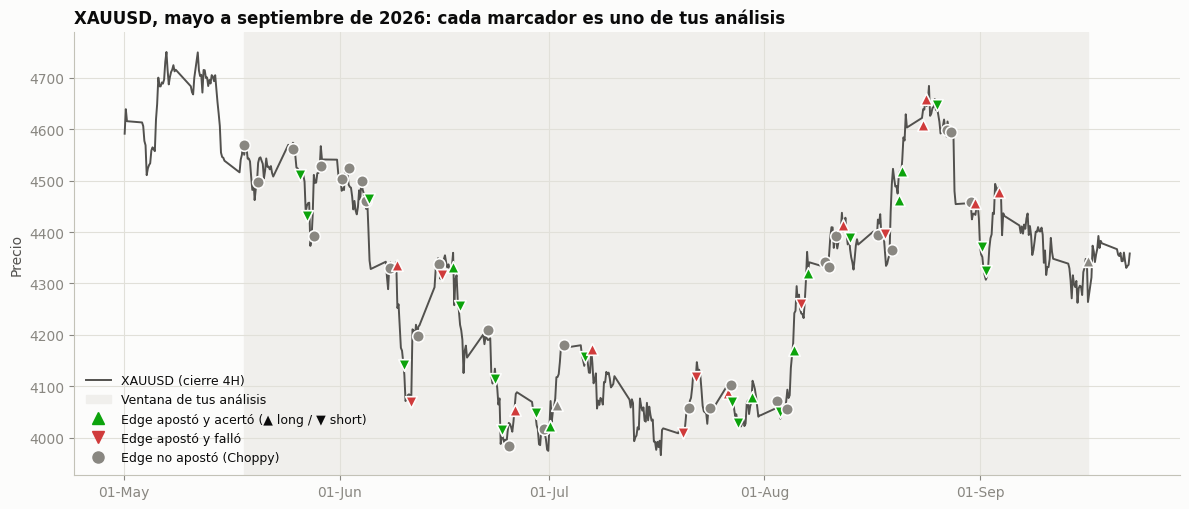

Rango: mín 3966 · máx 4750 · primer análisis 2026-05-18 · último 2026-09-16 · última vela 2026-09-22


In [6]:
prov_x, rows_x, _ = DATA["XAUUSD"]
velas = prov_x._load_tf("4H")
velas = velas[velas["time"] >= "2026-05-01"]

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(velas["time"], velas["close"], color=INK2, lw=1.4, label="XAUUSD (cierre 4H)")
t0 = min(r.timestamp_entry for r in rows_x); t1 = max(r.timestamp_entry for r in rows_x)
ax.axvspan(t0, t1, color="#f0efec", zorder=0, label="Ventana de tus análisis")

for r in rows_x:
    d = bias_to_direction(r.bias_predicho_original)
    ok = None if (d is None or r.ground_truth_incompleto) else d == r.ground_truth_direction
    marker = {"long": "^", "short": "v", None: "o"}[d]
    color = MUTED if ok is None else (GOOD if ok else BAD)
    ax.scatter(r.timestamp_entry, r.entry_price, marker=marker, s=70, color=color,
               edgecolor=SURF, linewidth=1.2, zorder=3)

handles = [Line2D([], [], color=INK2, lw=1.4, label="XAUUSD (cierre 4H)"),
           plt.Rectangle((0, 0), 1, 1, color="#f0efec", label="Ventana de tus análisis"),
           Line2D([], [], ls="", marker="^", ms=8, color=GOOD, label="Edge apostó y acertó (▲ long / ▼ short)"),
           Line2D([], [], ls="", marker="v", ms=8, color=BAD, label="Edge apostó y falló"),
           Line2D([], [], ls="", marker="o", ms=8, color=MUTED, label="Edge no apostó (Choppy)")]
ax.legend(handles=handles, loc="lower left", fontsize=9)
ax.set_title("XAUUSD, mayo a septiembre de 2026: cada marcador es uno de tus análisis")
ax.set_ylabel("Precio")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.tight_layout(); plt.show()

print(f"Rango: mín {velas['close'].min():.0f} · máx {velas['close'].max():.0f} · "
      f"primer análisis {t0:%Y-%m-%d} · último {t1:%Y-%m-%d} · última vela {velas['time'].max():%Y-%m-%d}")

In [7]:
# ¿Fue un período direccional? Hacia dónde fue el precio en cada análisis, por mes.
todos = [r for n in ("XAUUSD", "BTCUSD") for r in DATA[n][1] if not r.ground_truth_incompleto]
por_mes = pd.crosstab(pd.Series([r.timestamp_entry.strftime("%Y-%m") for r in todos], name="Mes"),
                      pd.Series([r.ground_truth_direction for r in todos], name="El precio fue"))
por_mes.loc["Total"] = por_mes.sum()
por_mes

El precio fue,long,short
Mes,,
2026-05,4,3
2026-06,6,15
2026-07,10,10
2026-08,22,15
2026-09,1,3
Total,43,46


**Lectura:** en total el período fue **equilibrado**, 48% long y 52% short, pero con meses bien
direccionales: **junio fue bajista** (15 contra 6) y **agosto alcista** (22 contra 15). Los modelos se
probaron en los dos tipos de mercado, no solo en uno. En una versión anterior del análisis, con el bug del
reloj y menos datos, el período parecía muy bajista y "apostar siempre short" parecía ganarle al edge.
**Esa conclusión era falsa**: se debía al bug y a mirar solo una parte de los datos.

## 3. ¿El edge completo acierta? (pruebas fijadas de antemano)

Estas son las únicas preguntas con reglas de decisión **fijadas antes de ver los resultados**
(plan `crea-un-plan-de-frolicking-kahn.md`). Por eso son la evidencia más confiable del cuaderno.

- **1a:** ¿acierta más que una moneda?
- **1b:** ¿le gana a "seguir la tendencia diaria" (precio contra EMA200 en 1D, calculada en el momento)?
- **1c:** ¿acierta más cuanto mayor es `|calc_edge|`?
- **2:** ¿existe un reparto de pesos P0–P4 mejor **fuera de muestra**?
- **3:** ¿se traduce en R positivo?

1a, 1b y 1c se corrigen juntas por Holm. Se usan las 3 cuentas.

**Qué cambió respecto del pre-registro.** El plan fijaba el ancla en la primera entrada, y el 23-sep se
encontró que eso mide desde más tarde que la decisión (§1.3). Se muestran las dos columnas: la corregida
es la que responde "¿el análisis acierta?", y la pre-registrada se conserva tal cual para no esconder
nada. La pregunta 3 no depende del ancla: usa el R de todos los trades ejecutados.

In [8]:
# Ancla corregida (momento del análisis) y, para trazabilidad, la pre-registrada (primera entrada).
cuentas_ev = [ev.load_account(db, os.path.join(MT5, carpeta), True, ANCHOR_MODE_ANALYSIS) for db, carpeta in CUENTAS.values()]
cuentas_pre = [ev.load_account(db, os.path.join(MT5, carpeta), True, ANCHOR_MODE_EXECUTION) for db, carpeta in CUENTAS.values()]
filas_ev = [r for a in cuentas_ev for r in a.rows]
filas_pre = [r for a in cuentas_pre for r in a.rows]
# El R de un trade no depende del ancla: la pregunta 3 usa todos los trades ejecutados. Con el
# ancla de análisis quedarían afuera los ejecutados cuyo análisis es retroactivo.
ejec = ev.executed_frame(filas_pre)
q1 = ev.run_question_1(filas_ev, seed=ev.DEFAULT_SEED)
q1_pre = ev.run_question_1(filas_pre, seed=ev.DEFAULT_SEED)
q2 = ev.run_question_2(filas_ev)
q2_pre = ev.run_question_2(filas_pre)
q3 = ev.run_question_3(ejec, seed=ev.DEFAULT_SEED)

def celda(t):
    return f"{t.statistic} · p Holm {t.p_holm:.3f} · {'✅ señal' if t.signal else 'no concluyente'}"
veredicto = [{"#": t.key, "Pregunta": t.question, "Ancla corregida (momento del análisis)": celda(t),
              "Ancla pre-registrada (primera entrada)": celda(tp)} for t, tp in zip(q1, q1_pre)]
w2 = lambda q: (f"óptimo {q.wf['óptimo'].accuracy*100:.1f}% vs actuales {q.wf['actuales'].accuracy*100:.1f}% (walk-forward) · "
                + ("✅ señal" if q.signal else "no concluyente"))
veredicto.append({"#": "2", "Pregunta": "¿Pesos mejores fuera de muestra?",
                  "Ancla corregida (momento del análisis)": w2(q2), "Ancla pre-registrada (primera entrada)": w2(q2_pre)})
r3 = (f"{q3.expectancy:+.2f}R por trade, IC95 [{q3.ci[0]:+.2f}, {q3.ci[1]:+.2f}], n={q3.n} · "
      + ("✅ señal" if q3.signal else "no concluyente"))
veredicto.append({"#": "3", "Pregunta": "¿R positivo?", "Ancla corregida (momento del análisis)": r3 + " (no depende del ancla)",
                  "Ancla pre-registrada (primera entrada)": r3})
pd.DataFrame(veredicto).set_index("#")

,Pregunta,Ancla corregida (momento del análisis),Ancla pre-registrada (primera entrada)
#,,,
1a,¿Acierta más que el azar?,36/60 = 60.0% · p Holm 0.465 · no concluyente,42/61 = 68.9% · p Holm 0.013 · ✅ señal
1b,¿Le gana a seguir la tendencia 1D?,discordantes: edge 19 vs tendencia 11 (de 60 pares) · p Holm 0.465 · no concluyente,discordantes: edge 20 vs tendencia 8 (de 61 pares) · p Holm 0.071 · no concluyente
1c,¿Acierta más con edge más fuerte?,r = +0.169 entre magnitud del edge y acierto (n=60) · p Holm 0.465 · no concluyente,r = +0.166 entre magnitud del edge y acierto (n=61) · p Holm 0.201 · no concluyente
2,¿Pesos mejores fuera de muestra?,óptimo 63.9% vs actuales 63.6% (walk-forward) · no concluyente,óptimo 66.7% vs actuales 66.7% (walk-forward) · no concluyente
3,¿R positivo?,"+0.17R por trade, IC95 [-0.26, +0.62], n=37 · no concluyente (no depende del ancla)","+0.17R por trade, IC95 [-0.26, +0.62], n=37 · no concluyente"


In [9]:
# Los baselines: reglas ingenuas calculadas solo con información disponible en el momento.
bets = ev.edge_bets(filas_ev)
mayoria = ev.hindsight_majority(filas_ev)
reglas = [("Edge P0–P4 (tu sistema)", lambda r: r.edge_dir),
          ("Tendencia 1D: precio vs EMA200 diaria", lambda r: r.baselines.get("B1")),
          ("Tendencia 4H: precio vs EMA200 4H", lambda r: r.baselines.get("B2")),
          ("Momentum: últimas 20 velas de 4H", lambda r: r.baselines.get("B3")),
          (f"Siempre {mayoria} (⚠️ usa retrospectiva)", lambda r: mayoria)]
filas = []
for nombre, f in reglas:
    ok, n = ev._acc_line(filas_ev, f); lo, hi = wilson_interval(ok, n)
    ok2, n2 = ev._acc_line(bets, f)
    if nombre.startswith("Edge"):
        mc = "—"
    else:
        b = sum(1 for r in bets if f(r) and r.edge_hit and f(r) != r.gt_thesis)
        c = sum(1 for r in bets if f(r) and not r.edge_hit and f(r) == r.gt_thesis)
        mc = f"edge {b} vs regla {c} · p={ev.mcnemar_exact(b, c):.2f}"
    filas.append({"Regla": nombre, "En todos los resueltos": f"{ok}/{n} = {ok/n*100:.0f}% [{lo*100:.0f}–{hi*100:.0f}]",
                  "En los análisis donde apostó tu edge": f"{ok2}/{n2} = {ok2/n2*100:.0f}%",
                  "Desacuerdos con el edge": mc})
pd.DataFrame(filas).set_index("Regla")

,En todos los resueltos,En los análisis donde apostó tu edge,Desacuerdos con el edge
Regla,,,
Edge P0–P4 (tu sistema),36/60 = 60% [47–71],36/60 = 60%,—
Tendencia 1D: precio vs EMA200 diaria,43/96 = 45% [35–55],28/60 = 47%,edge 19 vs regla 11 · p=0.20
Tendencia 4H: precio vs EMA200 4H,56/96 = 58% [48–68],39/60 = 65%,edge 7 vs regla 10 · p=0.63
Momentum: últimas 20 velas de 4H,57/96 = 59% [49–69],37/60 = 62%,edge 8 vs regla 9 · p=1.00
Siempre short (⚠️ usa retrospectiva),50/96 = 52% [42–62],33/60 = 55%,edge 17 vs regla 14 · p=0.72


In [10]:
# Pesos P0-P4 fuera de muestra (pregunta 2) y potencia (qué puede responder esta muestra)
w = pd.DataFrame([{"Pesos": k, "In-sample (inflado)": f"{q2.in_sample['óptimo in-sample' if k == 'óptimo' else k].accuracy*100:.1f}%",
                   "Walk-forward (fuera de muestra)": f"{q2.wf[k].accuracy*100:.1f}%",
                   "Dejando uno afuera (fuera de muestra)": f"{q2.loo[k].accuracy*100:.1f}%"}
                  for k in ("óptimo", "actuales", "iguales", "solo P2")]).set_index("Pesos")
print("Óptimo elegido en toda la muestra (P0/P1/P2/P3/P4):", tuple(round(x, 2) for x in q2.in_sample_best))
display(w)
pot = pd.DataFrame([{"Pregunta": p.question, "n": p.n_now, "Observado": p.observed,
                     "Brecha detectable": p.min_detectable, "n necesario": p.n_needed,
                     "Meses más": "ya alcanza" if p.months_more == 0 else (None if p.months_more is None else round(p.months_more))}
                    for p in ev.power_projection(filas_ev, ejec)]).set_index("Pregunta")
pot

Óptimo elegido en toda la muestra (P0/P1/P2/P3/P4): (0.0, 0.4, 0.05, 0.15, 0.4)


,In-sample (inflado),Walk-forward (fuera de muestra),Dejando uno afuera (fuera de muestra)
Pesos,,,
óptimo,65.3%,63.9%,63.2%
actuales,60.0%,63.6%,60.0%
iguales,58.7%,61.8%,58.7%
solo P2,58.8%,68.0%,58.8%


,n,Observado,Brecha detectable,n necesario,Meses más
Pregunta,,,,,
1a (vs azar),60,60.0% vs 50%,±18 pts,194,5
1b (vs tendencia 1D),60,60.0% vs 46.7%,±18 pts,109,2
3 (expectancy > 0),37,+0.17R (sd 1.41),±0.65R,538,38


In [11]:
# Brecha de ejecución: ¿la tesis estructural y el trade real terminan igual?
g = ev.execution_gap(ejec)
tot = g.direction_agree + g.direction_disagree
display(pd.DataFrame({"Trade ganó": [g.confirmed_won, g.invalidated_won],
                      "Trade perdió": [g.confirmed_lost, g.invalidated_lost]},
                     index=["Tesis confirmada", "Tesis invalidada"]))
print(f"La dirección según la tesis y según el trade coincide en {g.direction_agree}/{tot} trades ejecutados "
      f"({g.direction_agree/tot*100:.0f}%); difiere en {g.direction_disagree} ({g.direction_disagree/tot*100:.0f}%).")

,Trade ganó,Trade perdió
Tesis confirmada,12,6
Tesis invalidada,4,15


La dirección según la tesis y según el trade coincide en 27/37 trades ejecutados (73%); difiere en 10 (27%).


**Lectura:**
- **1a cambia de respuesta según desde dónde se mide.** Desde la entrada, 69% (señal). Desde el
  análisis, 60%, que con 60 apuestas **no se distingue del azar**. Hay dos explicaciones posibles, y con
  estos datos no se pueden separar:
  1. esperar confirmación antes de entrar agrega valor real, y tu ventaja está en **cuándo** entrás;
  2. medir desde más tarde simplemente facilita acertar, porque parte del recorrido ya ocurrió.
- **1b y 1c no son concluyentes.** Vas adelante de la tendencia diaria, pero podría ser suerte.
- **Reglas simples de 4H aciertan igual o más que tu edge** en los mismos análisis: tendencia de 4H 65%,
  momentum 62%, edge 60%. Los desacuerdos van parejos.
- **Pesos P0–P4:** el reparto "óptimo" de la muestra completa **no le gana a los pesos actuales fuera
  de muestra**, aunque es muy distinto de ellos. Es la señal clásica de sobreajuste: el óptimo se ajustó
  al ruido. **Mantené los pesos actuales**, no porque sean óptimos sino porque nada demostró ser mejor.
- **Plata (R):** positivo pero incierto. Confirmarlo requiere cientos de trades más.
- La columna **"Siempre short"** tiene una ventaja injusta, porque sabe hacia dónde fue el período. Se
  muestra solo como referencia.

## 4. P2: qué es y cómo se calcula el P2 sistemático

Hoy **P2 lo ponés a ojo** (−2 a +2). El P2 sistemático lo calcula con reglas fijas, en varias
temporalidades:

1. **Dirección en cada temporalidad:** +1 si `precio > EMA20 > (EMA100) > EMA200`, −1 si el orden
   está invertido, y 0 en cualquier otro caso.
2. **Filtro de DI** (modelos C a F): si los DI contradicen a las EMAs, esa temporalidad vale 0.
3. **Fuerza por ADX14:** ×1 si ADX > 25, ×0.5 si está entre 20 y 25, y ×0 si es menor que 20.
4. **Suma ponderada por temporalidad**, reescalada a −2..+2 como tu P2.

Los parámetros (EMA 20/100/200, ADX 14, umbrales 20 y 25) son **valores estándar de manual**, fijados
antes de mirar los datos. **Ninguno se ajustó con los resultados.**

In [12]:
filas = []
for m in MODELS:
    pico = max(m.weights, key=m.weights.get)
    filas.append({"Modelo": m.name, "Descripción": m.label.split("— ")[-1],
                  "EMAs": "/".join(map(str, m.ema_chain)), "DI": "sí" if m.use_di else "no",
                  "Temporalidades": " ".join(m.timeframes), "Peso mayor": f"{pico} ({m.weights[pico]:.2f})",
                  "Pesos": " · ".join(f"{tf} {w:.2f}" for tf, w in m.weights.items()),
                  "Definido": "después de ver datos ⚠️" if m.name == "F" else "antes de ver datos"})
pd.DataFrame(filas).set_index("Modelo")

,Descripción,EMAs,DI,Temporalidades,Peso mayor,Pesos,Definido
Modelo,,,,,,,
A,"baseline (EMA20/200, ADX)",20/200,no,1W 1D 12H 4H 1H,1W (0.30),1W 0.30 · 1D 0.25 · 12H 0.20 · 4H 0.15 · 1H 0.10,antes de ver datos
B,+ EMA100,20/100/200,no,1W 1D 12H 4H 1H,12H (0.30),1W 0.15 · 1D 0.20 · 12H 0.30 · 4H 0.20 · 1H 0.15,antes de ver datos
C,+ EMA100 + DI,20/100/200,sí,1W 1D 12H 4H 1H,12H (0.30),1W 0.15 · 1D 0.20 · 12H 0.30 · 4H 0.20 · 1H 0.15,antes de ver datos
D,B+C + 30M,20/100/200,sí,1W 1D 12H 4H 1H 30M,1H (0.26),1W 0.08 · 1D 0.12 · 12H 0.17 · 4H 0.22 · 1H 0.26 · 30M 0.15,antes de ver datos
E,B+C+D + 15M,20/100/200,sí,1W 1D 12H 4H 1H 30M 15M,1H (0.24),1W 0.07 · 1D 0.10 · 12H 0.14 · 4H 0.19 · 1H 0.24 · 30M 0.16 · 15M 0.10,antes de ver datos
F,"pico 1H, sin 30M (D simplificado)",20/100/200,sí,1W 1D 12H 4H 1H,1H (0.31),1W 0.09 · 1D 0.14 · 12H 0.20 · 4H 0.26 · 1H 0.31,después de ver datos ⚠️


## 5. Dentro del edge, P2 no puede cambiar ninguna decisión

Antes de comparar modelos hay que saber si **sustituir P2 cambia algo**. P2 pesa `0.15 / 2 = 0.075`
por punto en `calc_edge`, y el umbral entre Choppy y direccional es ±0.26. Un cambio de P2 de un par de
puntos casi nunca alcanza para cruzarlo.

In [13]:
# Datos para toda la sección P2: XAUUSD + BTC (US100 no tiene historia semanal suficiente)
P2 = [(n, r) for n in ("XAUUSD", "BTCUSD") for r in DATA[n][1]
      if not r.ground_truth_incompleto and r.ground_truth_direction]
P2.sort(key=lambda x: x[1].timestamp_entry)
truth = np.array([1 if r.ground_truth_direction == "long" else -1 for _, r in P2])
print(f"Análisis resueltos con P2 sistemático: {len(P2)}  "
      f"(XAUUSD {sum(n == 'XAUUSD' for n, _ in P2)}, BTC {sum(n == 'BTCUSD' for n, _ in P2)})")

filas = []
for m in MODELS:
    cambia = invierte = 0; hits = apuestas = 0
    for _, r in P2:
        mr = r.model_results[m.name]
        if mr.bias_predicho and mr.bias_predicho != r.bias_predicho_original:
            cambia += 1
            if bias_to_direction(mr.bias_predicho) and bias_to_direction(r.bias_predicho_original):
                invierte += 1
        if mr.match is not None:
            apuestas += 1; hits += mr.match
    filas.append({"Modelo": m.name, "Bias distinto al tuyo": cambia, "Dirección invertida": invierte,
                  "Edge con este P2": f"{hits}/{apuestas} = {hits/apuestas*100:.1f}%"})
orig = [r.match_original for _, r in P2 if r.match_original is not None]
filas.append({"Modelo": "Tu P2", "Bias distinto al tuyo": "—", "Dirección invertida": "—",
              "Edge con este P2": f"{sum(orig)}/{len(orig)} = {sum(orig)/len(orig)*100:.1f}%"})
pd.DataFrame(filas).set_index("Modelo")

Análisis resueltos con P2 sistemático: 89  (XAUUSD 67, BTC 22)


,Bias distinto al tuyo,Dirección invertida,Edge con este P2
Modelo,,,
A,10,0,29/45 = 64.4%
B,5,0,30/50 = 60.0%
C,5,0,30/50 = 60.0%
D,4,0,30/49 = 61.2%
E,4,0,30/49 = 61.2%
F,6,0,30/49 = 61.2%
Tu P2,—,—,32/54 = 59.3%


**Lectura:** **ningún modelo invierte una sola dirección** (columna en cero), y la puntería del edge
casi no se mueve. Automatizar P2 **no cambia tus trades**: el beneficio es tiempo, consistencia y
objetividad. Si en algún momento querés que P2 pese en la decisión, eso es otra decisión (subir su
peso) y necesita su propia prueba.

## 6. P2 solo: ¿qué tan bien predice la dirección?

Se toma **solo P2** y se ignoran P0, P1, P3 y P4: positivo predice que sube, negativo que baja, 0 no opina.

- **Todos:** los 89 análisis.
- **Direccionales:** solo los análisis donde tu edge dijo Bullish o Bearish.
- **Choppy:** solo los análisis donde tu edge no apostó.

In [14]:
def pred(model):
    # +1/-1/0 por análisis, recalculado desde las velas en el momento exacto del análisis
    out = []
    for n, r in P2:
        snaps = SNAPS[(n, r.trade_id)]
        v = rescale_p2_sistematico(compute_score_p2_sistematico(snaps, model)[0])
        out.append(0 if not v else (1 if v > 0 else -1))
    return np.array(out)

SNAPS = {(n, r.trade_id): {tf: DATA[n][0].get_indicator_snapshot(tf, r.timestamp_entry) for tf in ALL_TIMEFRAMES}
         for n, r in P2}
PRED = {m.name: pred(m) for m in MODELS}
PRED["Tu P2"] = np.array([0 if not r.p2_discrecional else (1 if r.p2_discrecional > 0 else -1) for _, r in P2])
choppy = np.array([r.bias_predicho_original == "Choppy / Neutral" for _, r in P2])

def puntos(p, mask=None):
    mask = np.ones(len(p), bool) if mask is None else mask
    a = (p != 0) & mask; k = int((a & (p == truth)).sum()); n = int(a.sum())
    return k, n

filas = []
for nombre, p in PRED.items():
    fila = {"Predictor": nombre, "Neto (aciertos − fallos)": int(net_score(p, truth)[0])}
    for col, mask in (("Todos", None), ("Direccionales", ~choppy), ("Choppy", choppy)):
        k, n = puntos(p, mask); lo, hi = wilson_interval(k, n) if n else (np.nan, np.nan)
        fila[col] = f"{k}/{n} = {k/n*100:.0f}% [{lo*100:.0f}–{hi*100:.0f}]" if n else "—"
    k, n = puntos(p); fila["Opina en"] = f"{n/len(p)*100:.0f}%"
    filas.append(fila)
pd.DataFrame(filas).set_index("Predictor")

,Neto (aciertos − fallos),Todos,Direccionales,Choppy,Opina en
Predictor,,,,,
A,2,29/56 = 52% [39–64],21/35 = 60% [44–74],8/21 = 38% [21–59],63%
B,1,20/39 = 51% [36–66],14/25 = 56% [37–73],6/14 = 43% [21–67],44%
C,0,18/36 = 50% [34–66],14/24 = 58% [39–76],4/12 = 33% [14–61],40%
D,12,25/38 = 66% [50–79],20/27 = 74% [55–87],5/11 = 45% [21–72],43%
E,11,24/37 = 65% [49–78],19/26 = 73% [54–86],5/11 = 45% [21–72],42%
F,9,26/43 = 60% [46–74],21/29 = 72% [54–85],5/14 = 36% [16–61],48%
Tu P2,6,26/46 = 57% [42–70],21/31 = 68% [50–81],5/15 = 33% [15–58],52%


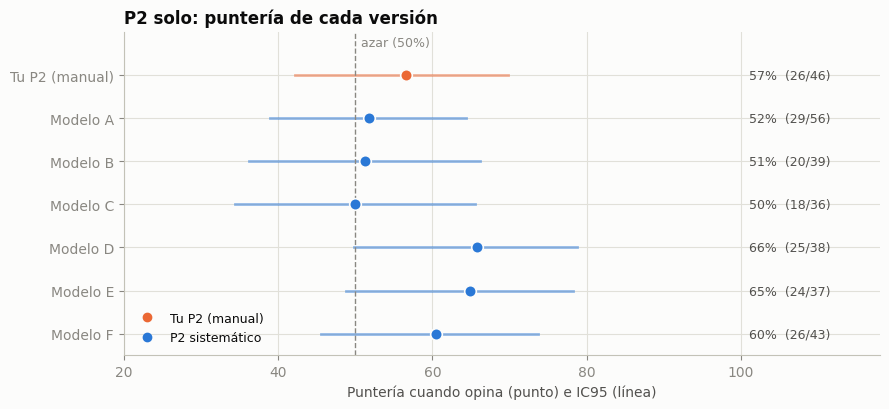

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.2))
orden = ["Tu P2"] + [m.name for m in MODELS]
for i, nombre in enumerate(orden):
    k, n = puntos(PRED[nombre]); lo, hi = wilson_interval(k, n)
    c = ORANGE if nombre == "Tu P2" else BLUE
    ax.plot([lo * 100, hi * 100], [i, i], color=c, lw=2, alpha=0.5)
    ax.scatter(k / n * 100, i, s=70, color=c, edgecolor=SURF, linewidth=1.2, zorder=3)
    ax.text(101, i, f"{k/n*100:.0f}%  ({k}/{n})", va="center", fontsize=9, color=INK2)
ax.axvline(50, color=MUTED, ls="--", lw=1)
ax.text(50.8, -0.75, "azar (50%)", color=MUTED, fontsize=9, ha="left", va="center")
ax.set_yticks(range(len(orden)), [("Tu P2 (manual)" if o == "Tu P2" else f"Modelo {o}") for o in orden])
ax.set_xlim(20, 118); ax.set_ylim(len(orden) - 0.5, -1.0); ax.set_xlabel("Puntería cuando opina (punto) e IC95 (línea)")
ax.set_title("P2 solo: puntería de cada versión")
ax.legend(handles=[Line2D([], [], ls="", marker="o", color=ORANGE, label="Tu P2 (manual)"),
                   Line2D([], [], ls="", marker="o", color=BLUE, label="P2 sistemático")],
          loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

**Lectura:**
- **D (66%) y F (60%) son los que mejor salen; A, B y C quedan en 50–52%**, como una moneda. Tu P2
  manual, 57%.
- **Los intervalos se superponen mucho:** ninguna versión se separa claramente del azar ni de las demás.
- **En los análisis direccionales todos mejoran** (F 72%, D 74%, tu P2 68%), y **en los Choppy todos
  aciertan menos que una moneda**, también el tuyo. Que el edge no apueste en Choppy es la decisión
  correcta. Ojo: separar por direccional o Choppy es exploratorio, y cada grupo tiene pocos casos.

## 7. ¿Qué mejoró al modelo D? (experimento 2×2)

D difería de C en dos cosas a la vez: **agregar 30M** y **mover el pico de peso de 12H a 1H**. Se
aislaron cambiando una sola cosa por vez, con las mismas reglas (EMA100 + DI) en los cuatro casos.

In [16]:
C = MODEL_C.weights
VAR = {
    "C · pico 12H · sin 30M": MODEL_C,
    "C + 30M · pico 12H": replace(MODEL_C, name="C30", timeframes=MODEL_C.timeframes + ("30M",),
                                  weights={**{k: v * 0.85 for k, v in C.items()}, "30M": 0.15}),
    "F · pico 1H · sin 30M": MODEL_F,
    "D · pico 1H · con 30M": MODEL_D,
}
PV = {k: pred(m) for k, m in VAR.items()}
val = lambda p: np.where(p == 0, 0, np.where(p == truth, 1, -1))

display(pd.DataFrame([{"Variante": k, "Aciertos": f"{puntos(p)[0]}/{puntos(p)[1]}",
                       "Puntería": f"{puntos(p)[0]/puntos(p)[1]*100:.1f}%",
                       "Neto": int(net_score(p, truth)[0])} for k, p in PV.items()]).set_index("Variante"))

def comparar(a, b):
    d = val(PV[b]) - val(PV[a]); up, dn = int((d > 0).sum()), int((d < 0).sum())
    return up, dn, binomial_test_two_sided(min(up, dn), up + dn) if up + dn else 1.0

filas = []
for que, a, b in (("Mover el pico a 1H (sin 30M)", "C · pico 12H · sin 30M", "F · pico 1H · sin 30M"),
                  ("Agregar 30M (con pico en 1H)", "F · pico 1H · sin 30M", "D · pico 1H · con 30M"),
                  ("Agregar 30M (con pico en 12H)", "C · pico 12H · sin 30M", "C + 30M · pico 12H")):
    up, dn, p = comparar(a, b)
    filas.append({"Cambio": que, "Análisis que mejora": up, "Que empeora": dn, "p (test de signo)": round(p, 3)})
pd.DataFrame(filas).set_index("Cambio")

,Aciertos,Puntería,Neto
Variante,,,
C · pico 12H · sin 30M,18/36,50.0%,0
C + 30M · pico 12H,19/33,57.6%,5
F · pico 1H · sin 30M,26/43,60.5%,9
D · pico 1H · con 30M,25/38,65.8%,12


,Análisis que mejora,Que empeora,p (test de signo)
Cambio,,,
Mover el pico a 1H (sin 30M),15,6,0.078
Agregar 30M (con pico en 1H),5,2,0.453
Agregar 30M (con pico en 12H),9,4,0.267


**Lectura:** **mover el peso a 1H ayuda** (mejora 15 análisis y empeora 6), pero con p=0.078 queda en el
borde: no es concluyente. Agregar 30M no suma nada claro en ninguno de los dos casos. Por eso **F**
(D sin 30M) queda cerca de D con una temporalidad menos. Antes de las correcciones esta mejora parecía
clara (p=0.004); buena parte de esa claridad venía de la vela en formación.

## 8. ¿Es sobreajuste? Seis pruebas

La sospecha es razonable: elegir **el mejor modelo después de mirar los datos** puede dar un resultado
que es solo suerte. Hay que separar tres riesgos distintos:

| Riesgo | ¿Aplica? | Por qué |
|---|---|---|
| **Entrenamiento:** parámetros ajustados para calzar con los resultados | **No** | EMAs, ADX, umbrales y reescalado son estándar y se fijaron antes. Los pesos de A a E se definieron antes de correr los modelos. Nada se optimizó contra los resultados. |
| **Selección:** quedarse con el mejor de varios intentos | **Sí** | F se definió **después** de ver la ablación. Elegir el mejor de 7 variantes infla su resultado. |
| **Look-ahead:** usar datos posteriores al análisis | **Sí, y se corrigió** | La vela en formación entraba con su cierre final, y el ancla llegaba tarde (§1.3). Todo lo que sigue ya está corregido. |

Las pruebas siguientes atacan el riesgo de selección.

### 8.1 Permutación con la selección incluida

Se mezclan al azar los resultados reales 10.000 veces y, en cada mezcla, se toma **el mejor de las 7
variantes**. Si el mejor real no supera claramente al "mejor por suerte", el hallazgo no vale. Mezclar
también conserva la proporción long/short, así que esta prueba **no premia** un sesgo del período.

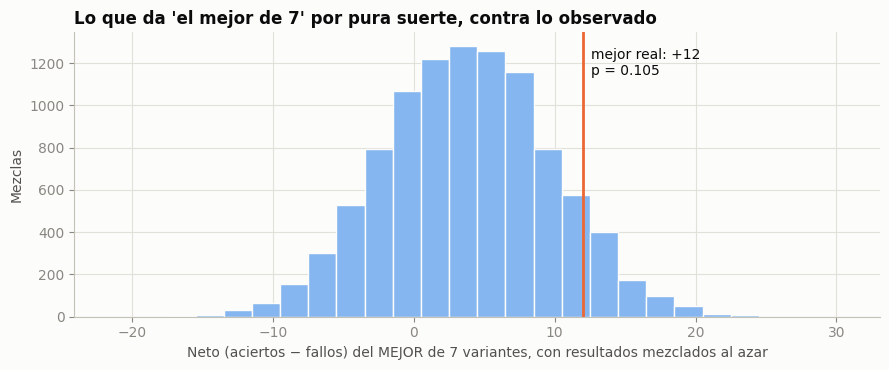

Mejor neto real: +12 · p = 0.105 (con la selección del mejor de 7 incluida)
Por suerte, el mejor de 7 da en promedio +3.8; el 95% de las veces no pasa de +14.
Neto real por variante: {'A': 2, 'B': 1, 'C': 0, 'D': 12, 'E': 11, 'F': 9, 'C + 30M · pico 12H': 5}


In [17]:
nombres7 = ["A", "B", "C", "D", "E", "F", "C + 30M · pico 12H"]
M7 = np.vstack([PRED[k] if k in PRED else PV[k] for k in nombres7])
obs, p_perm, nula = permutation_max_net_test(M7, truth, n_perm=10_000, seed=SEED)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(nula, bins=np.arange(nula.min() - 0.5, nula.max() + 1.5, 2), color="#86b6ef", edgecolor=SURF)
ax.axvline(obs, color=ORANGE, lw=2)
ax.text(obs + 0.6, ax.get_ylim()[1] * 0.85, f"mejor real: +{obs}\np = {p_perm:.3f}", color=INK, fontsize=10)
ax.set_xlabel("Neto (aciertos − fallos) del MEJOR de 7 variantes, con resultados mezclados al azar")
ax.set_ylabel("Mezclas")
ax.set_title("Lo que da 'el mejor de 7' por pura suerte, contra lo observado")
plt.tight_layout(); plt.show()
print(f"Mejor neto real: {obs:+d} · p = {p_perm:.3f} (con la selección del mejor de 7 incluida)")
print(f"Por suerte, el mejor de 7 da en promedio {nula.mean():+.1f}; el 95% de las veces no pasa de {np.quantile(nula, .95):+.0f}.")
print("Neto real por variante:", {k: int(net_score(v, truth)[0]) for k, v in zip(nombres7, M7)})

**Lectura:** el mejor neto real es +12 (modelo D), y por pura suerte el mejor de 7 llega a eso en **~1 de
cada 10 mezclas** (p=0.105). **No alcanza para descartar la suerte.** Antes de las correcciones esta
prueba daba p=0.023. La conclusión cambió: hoy no hay una señal de P2 sistemático que el sesgo de
selección pueda inflar, porque la señal misma no se distingue del azar.

### 8.2 Estabilidad en el tiempo: primera mitad contra segunda mitad

In [18]:
h = len(P2) // 2
filas = []
for etiqueta, sl in (("1ª mitad", slice(0, h)), ("2ª mitad", slice(h, len(P2)))):
    d0, d1 = P2[sl][0][1].timestamp_entry, P2[sl][-1][1].timestamp_entry
    fila = {"Tramo": f"{etiqueta} ({d0:%d-%b} a {d1:%d-%b})"}
    for k in ("F", "A", "C", "Tu P2"):
        p = PRED[k][sl]; t = truth[sl]; a = p != 0
        fila[k] = f"{int((a & (p == t)).sum())}/{int(a.sum())} · neto {int(net_score(p, t)[0]):+d}"
    filas.append(fila)
pd.DataFrame(filas).set_index("Tramo")

,F,A,C,Tu P2
Tramo,,,,
1ª mitad (18-May a 26-Jul),10/18 · neto +2,11/21 · neto +1,9/16 · neto +2,12/24 · neto +0
2ª mitad (27-Jul a 03-Sep),16/25 · neto +7,18/35 · neto +1,9/20 · neto -2,14/22 · neto +6


### 8.3 Por activo

In [19]:
filas = []
for activo in ("XAUUSD", "BTCUSD"):
    m = np.array([n == activo for n, _ in P2])
    fila = {"Activo": activo, "Análisis": int(m.sum())}
    for k in ("F", "A", "C", "Tu P2"):
        p = PRED[k][m]; t = truth[m]; a = p != 0
        fila[k] = f"{int((a & (p == t)).sum())}/{int(a.sum())} · neto {int(net_score(p, t)[0]):+d}"
    filas.append(fila)
pd.DataFrame(filas).set_index("Activo")

,Análisis,F,A,C,Tu P2
Activo,,,,,
XAUUSD,67,20/35 · neto +5,24/48 · neto +0,13/30 · neto -4,20/36 · neto +4
BTCUSD,22,6/8 · neto +4,5/8 · neto +2,5/6 · neto +4,6/10 · neto +2


**Lectura de 8.2 y 8.3:** F tiene neto positivo en las dos mitades (+2 y +7), y A casi cero en las dos
(+1 y +1). La primera mitad incluye el junio bajista y la segunda el agosto alcista. Por activo, F da +5
en XAUUSD y +4 en BTC, pero BTC tiene solo 8 apuestas de F. Son números chicos: con 18 y 25 apuestas por
mitad, cualquier diferencia de este tamaño es compatible con el azar.

### 8.4 Robustez: ¿el resultado depende de un punto exacto?

Se pasa **de a poco** de los pesos de C (a=0) a los de F (a=1), y más allá. Si F fuera un golpe de suerte,
el resultado saltaría justo en a=1. Si es una tendencia real, crecería de forma gradual.

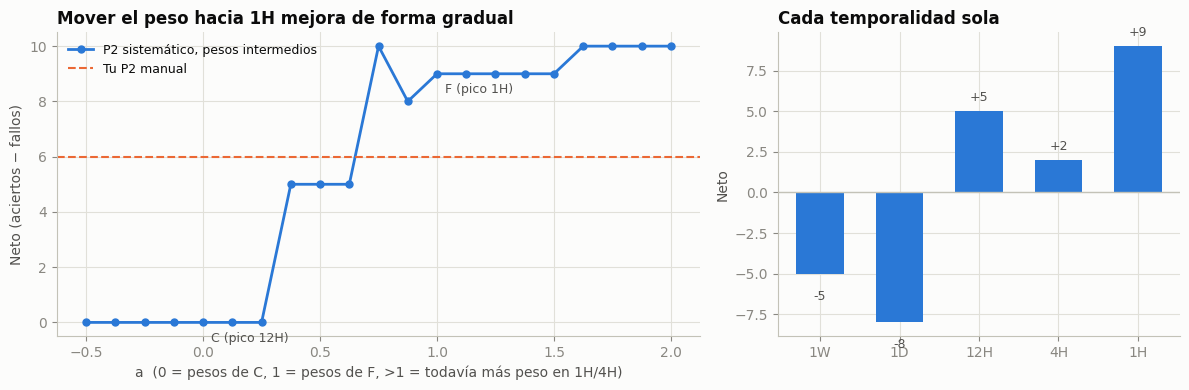

Neto por peso intermedio (a): {-0.5: 0, -0.375: 0, -0.25: 0, -0.125: 0, 0.0: 0, 0.125: 0, 0.25: 0, 0.375: 5, 0.5: 5, 0.625: 5, 0.75: 10, 0.875: 8, 1.0: 9, 1.125: 9, 1.25: 9, 1.375: 9, 1.5: 9, 1.625: 10, 1.75: 10, 1.875: 10, 2.0: 10}
Neto de cada temporalidad sola: {'1W': -5, '1D': -8, '12H': 5, '4H': 2, '1H': 9}


In [20]:
F_w = MODEL_F.weights
alphas = np.round(np.arange(-0.5, 2.01, 0.125), 3)
curva = []
for a in alphas:
    w = {tf: (1 - a) * C[tf] + a * F_w[tf] for tf in MODEL_C.timeframes}
    if min(w.values()) < 0:
        continue
    p = pred(replace(MODEL_C, name=f"a{a}", weights=w))
    curva.append((a, int(net_score(p, truth)[0])))
solo = {tf: int(net_score(pred(replace(MODEL_C, name=tf, timeframes=(tf,), weights={tf: 1.0})), truth)[0])
        for tf in MODEL_C.timeframes}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.6, 1]})
xs, ys = zip(*curva)
ax1.plot(xs, ys, color=BLUE, marker="o", ms=5, label="P2 sistemático, pesos intermedios")
ax1.axhline(int(net_score(PRED["Tu P2"], truth)[0]), color=ORANGE, ls="--", lw=1.5, label="Tu P2 manual")
for a, etiqueta in ((0, "C (pico 12H)"), (1, "F (pico 1H)")):
    y = dict(curva)[a]; ax1.annotate(etiqueta, (a, y), xytext=(6, -14), textcoords="offset points", fontsize=9, color=INK2)
ax1.set_xlabel("a  (0 = pesos de C, 1 = pesos de F, >1 = todavía más peso en 1H/4H)")
ax1.set_ylabel("Neto (aciertos − fallos)"); ax1.legend(fontsize=9, loc="upper left")
ax1.set_title("Mover el peso hacia 1H mejora de forma gradual")
ax2.bar(list(solo), list(solo.values()), color=BLUE, width=0.6)
ax2.axhline(0, color=AXIS, lw=1)
for i, (tf, v) in enumerate(solo.items()):
    ax2.text(i, v + (0.6 if v >= 0 else -1.6), f"{v:+d}", ha="center", fontsize=9, color=INK2)
ax2.set_title("Cada temporalidad sola"); ax2.set_ylabel("Neto")
plt.tight_layout(); plt.show()
print("Neto por peso intermedio (a):", {float(a): v for a, v in curva})
print("Neto de cada temporalidad sola:", solo)

In [21]:
# ¿Por qué 1H? Cuánto tarda el precio en tocar uno de los dos niveles
horas = []
for n, r in P2:
    up, lo = sorted([r.edge_validation_price, r.structural_invalidation], reverse=True)
    for i, b in enumerate(DATA[n][0].get_forward_path(r.timestamp_entry, 2160)):
        if b.high >= up or b.low <= lo:
            horas.append(i + 1); break
q = np.percentile(horas, [50, 75, 90])
print(f"Horas hasta que el precio toca un nivel: mediana {q[0]:.0f} · 75% {q[1]:.0f} · 90% {q[2]:.0f}")

Horas hasta que el precio toca un nivel: mediana 10 · 75% 19 · 90% 40


**Lectura:**
- **La curva sube de 0 a +9 o +10** a medida que el peso pasa a 1H, y después se mantiene. Tiene forma de
  escalón con meseta, no de pico casual, pero en toda la curva el neto nunca pasa de +10 sobre 43 apuestas.
- **Cada temporalidad sola:** 1W −5 y 1D −8 (peor que una moneda), 12H +5, 4H +2 y 1H +9. Lo diario y lo
  semanal, que antes parecían aportar, **miraban el cierre futuro de su propia vela**: con velas cerradas
  van en contra.
- **El horizonte:** el precio toca uno de tus niveles en una mediana de 10 horas (75% dentro de 19).
  Por eso 1H describe mejor lo que va a pasar en ese plazo.

### 8.5 ¿Acierta solo porque el período fue bajista?

In [22]:
f = PRED["F"]; a = f != 0
print(f"F dijo short {int((f < 0).sum())} veces y long {int((f > 0).sum())} veces.")
print(f"Cuando dijo long acertó {int(((f > 0) & (truth > 0)).sum())}/{int((f > 0).sum())}; "
      f"cuando dijo short, {int(((f < 0) & (truth < 0)).sum())}/{int((f < 0).sum())}.")
print(f"En esos mismos {int(a.sum())} análisis, 'siempre short' habría acertado {int((truth[a] < 0).sum())}/{int(a.sum())}.")

F dijo short 19 veces y long 24 veces.
Cuando dijo long acertó 15/24; cuando dijo short, 11/19.
En esos mismos 43 análisis, 'siempre short' habría acertado 20/43.


**Lectura:** F reparte sus apuestas de forma pareja (24 long, 19 short) y acierta parecido en las dos
direcciones (63% y 58%). En los mismos análisis, "siempre short" acertaría 47%. **No hay sesgo del período
detrás del resultado.**

### 8.6 F contra A: ¿F es realmente mejor que el modelo original?

In [23]:
d = val(PRED["F"]) - val(PRED["A"]); up, dn = int((d > 0).sum()), int((d < 0).sum())
ambos = (PRED["F"] != 0) & (PRED["A"] != 0)
filas = []
for k in ("A", "F"):
    kk, nn = puntos(PRED[k]); lo, hi = wilson_interval(kk, nn)
    filas.append({"Modelo": k, "Definido": "antes de ver datos" if k == "A" else "después de ver datos",
                  "Opina en": f"{nn}/{len(P2)} ({nn/len(P2)*100:.0f}%)",
                  "Precisión": f"{kk}/{nn} = {kk/nn*100:.1f}%  [{lo*100:.0f}–{hi*100:.0f}]",
                  "Neto": int(net_score(PRED[k], truth)[0]),
                  "Indicadores": "EMA20/200 + ADX" if k == "A" else "EMA20/100/200 + ADX + DI"})
display(pd.DataFrame(filas).set_index("Modelo"))
print(f"F mejora a A en {up} análisis y empeora en {dn} (test de signo p = {binomial_test_two_sided(min(up, dn), up + dn):.2f}).")
print(f"Donde los dos opinan ({int(ambos.sum())}), coinciden en la dirección {int((PRED['F'][ambos] == PRED['A'][ambos]).sum())} veces.")

,Definido,Opina en,Precisión,Neto,Indicadores
Modelo,,,,,
A,antes de ver datos,56/89 (63%),29/56 = 51.8% [39–64],2,EMA20/200 + ADX
F,después de ver datos,43/89 (48%),26/43 = 60.5% [46–74],9,EMA20/100/200 + ADX + DI


F mejora a A en 17 análisis y empeora en 10 (test de signo p = 0.25).
Donde los dos opinan (36), coinciden en la dirección 36 veces.


**Lectura:** F mejora a A en 17 análisis y empeora en 10 (p=0.25): **no es concluyente**. Cuando los dos
opinan dicen exactamente lo mismo (36 de 36). F es **A más selectivo**: opina menos y, cuando opina,
acierta más. Con velas cerradas, A queda en 52%, como una moneda, y F en 60%.

- **A:** opina en 63% de los análisis, usa menos indicadores y **no tiene sesgo de selección**.
- **F:** opina en 48%, con más precisión, pero se eligió mirando los datos.

Que F esté adelante sin ser concluyente es justo el caso para el que sirve registrar A en paralelo.

### 8.7 ¿El indicador funciona por sí solo? F en momentos al azar

Hasta acá, F se midió solo en los momentos que **vos** elegiste para analizar y con **tus** niveles. Para
saber si el indicador predice algo por sí mismo, se aplica F en 400 momentos al azar del mismo período
(XAUUSD), con niveles simétricos a la distancia típica de los tuyos, y se mide igual: qué nivel toca
primero el precio.

Hay dos grupos de momentos al azar: a **cualquier hora**, y solo **entre las 5:00 y las 8:59** (hora de
Guatemala), la franja en la que hacés la mayoría de tus análisis. Así se compara a la misma hora.

Tus análisis de XAUUSD entre las 5:00 y las 8:59: 55 de 67


Banda simétrica: ±40.0 pts (mediana de tus distancias). Momentos al azar resueltos: F al azar, a cualquier hora 399, F al azar, entre 5:00 y 8:59 313.


,Aciertos,IC95,Opina en,p vs azar (50%)
Dónde se aplica,,,,
F en TUS momentos (XAUUSD),20/35 = 57%,[41–72],52%,0.500
"F al azar, a cualquier hora",112/206 = 54%,[48–61],52%,0.236
"F al azar, entre 5:00 y 8:59",77/157 = 49%,[41–57],50%,0.873


F en tus momentos vs F al azar, a cualquier hora: +3 pts · p = 0.760 (dos proporciones, dos colas)
F en tus momentos vs F al azar, entre 5:00 y 8:59: +8 pts · p = 0.386 (dos proporciones, dos colas)


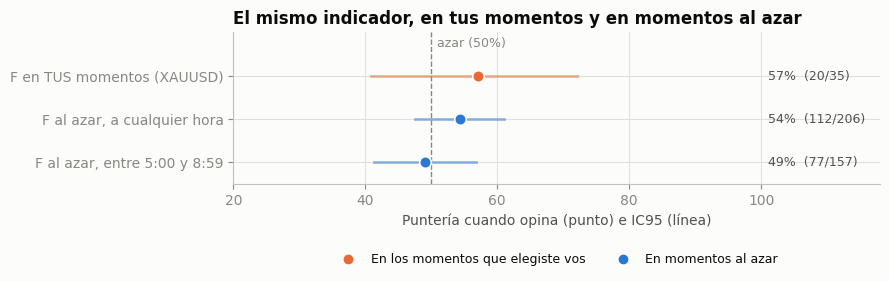

In [24]:
from core.p2_ground_truth import first_touch_direction, infer_thesis_direction
import math

prov_x = DATA["XAUUSD"][0]
xau = [r for n, r in P2 if n == "XAUUSD"]
dv = np.array([abs(r.edge_validation_price - r.entry_price) for r in xau])
di = np.array([abs(r.structural_invalidation - r.entry_price) for r in xau])
banda = float(np.median((dv + di) / 2))

h1 = prov_x._load_tf("1H")
t0, t1 = min(r.timestamp_entry for r in xau), max(r.timestamp_entry for r in xau)
todas = h1[(h1["time"] >= t0) & (h1["time"] <= t1)]
manana = todas[todas["time"].dt.hour.between(5, 8)]   # la franja de 2 de cada 3 de tus análisis
horas_tuyas = pd.Series([r.timestamp_entry.hour for r in xau])
print(f"Tus análisis de XAUUSD entre las 5:00 y las 8:59: {int(horas_tuyas.between(5, 8).sum())} de {len(xau)}")

def al_azar(cand, modelo):
    rng = np.random.default_rng(SEED)
    elegidos = rng.choice(len(cand), size=min(400, len(cand)), replace=False)
    pares = []
    for a in sorted(cand["time"].iloc[elegidos] + pd.Timedelta(minutes=30)):   # a mitad de vela, como un análisis real
        a = a.to_pydatetime()
        ep = prov_x.last_closed_close("15M", a)                                 # el precio visible en ese momento
        g, inc = first_touch_direction("long", prov_x.get_forward_path(a, 2160), ep, ep + banda, ep - banda)
        if inc or not g:
            continue
        sn = {tf: prov_x.get_indicator_snapshot(tf, a) for tf in modelo.timeframes}
        v = rescale_p2_sistematico(compute_score_p2_sistematico(sn, modelo)[0])
        pares.append((0 if not v else (1 if v > 0 else -1), 1 if g == "long" else -1))
    return pares

azar = {"F al azar, a cualquier hora": al_azar(todas, MODEL_F),
        "F al azar, entre 5:00 y 8:59": al_azar(manana, MODEL_F)}

en_xau = np.array([n == "XAUUSD" for n, _ in P2])
k_h, n_h = puntos(PRED["F"], en_xau)
print(f"Banda simétrica: ±{banda:.1f} pts (mediana de tus distancias). Momentos al azar resueltos: "
      + ", ".join(f"{k} {len(v)}" for k, v in azar.items()) + ".")

filas, puntos_graf = [], []
for etiqueta, k, n, cobertura in (
        ("F en TUS momentos (XAUUSD)", k_h, n_h, n_h / int(en_xau.sum())),
        *[(nom, sum(p == g for p, g in v if p), sum(1 for p, _ in v if p),
           sum(1 for p, _ in v if p) / len(v)) for nom, v in azar.items()]):
    lo, hi = wilson_interval(k, n)
    filas.append({"Dónde se aplica": etiqueta, "Aciertos": f"{k}/{n} = {k/n*100:.0f}%",
                  "IC95": f"[{lo*100:.0f}–{hi*100:.0f}]", "Opina en": f"{cobertura*100:.0f}%",
                  "p vs azar (50%)": f"{binomial_test_two_sided(k, n):.3f}"})
    puntos_graf.append((etiqueta, k, n, lo, hi))
display(pd.DataFrame(filas).set_index("Dónde se aplica"))

# ¿La diferencia entre tus momentos y los momentos al azar es real? (dos proporciones, aproximación normal)
for nombre, v in azar.items():
    k_a = sum(p == g for p, g in v if p); n_a = sum(1 for p, _ in v if p)
    pool = (k_h + k_a) / (n_h + n_a)
    z = (k_h / n_h - k_a / n_a) / math.sqrt(pool * (1 - pool) * (1 / n_h + 1 / n_a))
    print(f"F en tus momentos vs {nombre}: {100*(k_h/n_h - k_a/n_a):+.0f} pts · "
          f"p = {math.erfc(abs(z) / math.sqrt(2)):.3f} (dos proporciones, dos colas)")

fig, ax = plt.subplots(figsize=(9, 3.3))
for i, (etiqueta, k, n, lo, hi) in enumerate(puntos_graf):
    c = ORANGE if "TUS" in etiqueta else BLUE
    ax.plot([lo * 100, hi * 100], [i, i], color=c, lw=2, alpha=0.5)
    ax.scatter(k / n * 100, i, s=70, color=c, edgecolor=SURF, linewidth=1.2, zorder=3)
    ax.text(101, i, f"{k/n*100:.0f}%  ({k}/{n})", va="center", fontsize=9, color=INK2)
ax.axvline(50, color=MUTED, ls="--", lw=1)
ax.text(50.8, -0.75, "azar (50%)", color=MUTED, fontsize=9, ha="left", va="center")
ax.set_yticks(range(len(puntos_graf)), [e for e, *_ in puntos_graf])
ax.set_xlim(20, 118); ax.set_ylim(len(puntos_graf) - 0.5, -1.0)
ax.set_xlabel("Puntería cuando opina (punto) e IC95 (línea)")
ax.set_title("El mismo indicador, en tus momentos y en momentos al azar")
ax.legend(handles=[Line2D([], [], ls="", marker="o", color=ORANGE, label="En los momentos que elegiste vos"),
                   Line2D([], [], ls="", marker="o", color=BLUE, label="En momentos al azar")],
          loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

**Lectura:** **F acierta lo mismo en tus momentos que en momentos al azar**: 57% contra 54% a cualquier
hora y 49% en tu franja horaria. Ninguna de las tres cifras se separa de una moneda.

La versión anterior de este cuaderno concluía que la ventaja estaba en tu selección de setups: 71% en tus
momentos contra 50% al azar. **Esa diferencia venía de los dos sesgos de §1.3.** Corregidos, no queda
diferencia.

Implicancias:
- F **no sirve como señal independiente** (alertas, automatización en momentos arbitrarios).
- Tampoco hay evidencia de que funcione mejor dentro de tus análisis. Si aporta algo, será en
  combinación con tu criterio (§9), y eso lo tiene que mostrar el test con análisis nuevos.

### 8.8 Dos controles más: geometría de los niveles y minuto del ancla

- **Geometría:** el acierto es qué nivel toca primero el precio. Si uno de los dos suele estar más cerca,
  gana más seguido por pura distancia. ¿F está "cobrando" esa distancia?
- **Minuto del ancla:** la DB no guarda la hora en que decidiste P2, solo la de "Confirm & Save". El ancla
  usa `created_at` − 15 min. ¿Cambian los resultados si ese número está mal?

In [25]:
d2i = {"long": 1, "short": -1}
dist_v = np.array([abs(r.edge_validation_price - r.entry_price) for _, r in P2])
dist_i = np.array([abs(r.structural_invalidation - r.entry_price) for _, r in P2])
por_distancia = float(np.mean(dist_i / (dist_v + dist_i)))   # P(tocar la validación primero) si el precio fuera al azar
confirmada = float(np.mean([r.ground_truth_direction == r.thesis_direction for _, r in P2]))
print(f"Tu validación queda a {np.median(dist_v / dist_i):.2f}× la distancia de tu invalidación (mediana).")
print(f"Tesis confirmada: esperado por pura distancia {por_distancia*100:.0f}% · real {confirmada*100:.0f}%.")

cercano = np.array([1 if ((r.edge_validation_price if dv_ < di_ else r.structural_invalidation) > r.entry_price) else -1
                    for (_, r), dv_, di_ in zip(P2, dist_v, dist_i)])
tesis = np.array([d2i[r.thesis_direction] for _, r in P2])
f = PRED["F"]
filas = []
for etiqueta, pred_, mask in (("Siempre la dirección de tu tesis", tesis, None),
                              ("Siempre hacia el nivel más cercano", cercano, None),
                              ("F (todas sus apuestas)", f, None),
                              ("F cuando apunta al nivel más cercano", f, f == cercano),
                              ("F cuando apunta al nivel más lejano", f, f == -cercano)):
    k, n = puntos(pred_, mask); lo, hi = wilson_interval(k, n)
    filas.append({"Predictor": etiqueta, "Aciertos": f"{k}/{n} = {k/n*100:.0f}%", "IC95": f"[{lo*100:.0f}–{hi*100:.0f}]"})
display(pd.DataFrame(filas).set_index("Predictor"))

# Momento: ¿cuánto cambia si el ancla se corre unos minutos? created_at es el "Confirm & Save",
# posterior a P2, y la DB no guarda la hora exacta en que decidiste P2.
filas = []
for minutos in (0, 5, 10, 15, 30, 60):
    rows = [r for n in ("XAUUSD", "BTCUSD")
            for r in cargar(n, analysis_lead=timedelta(minutes=minutos))[1]]
    filas.append({"Ancla": f"created_at − {minutos} min" + ("  ← la usada" if minutos == 15 else ""), **medir(rows)})
display(pd.DataFrame(filas).set_index("Ancla"))

Tu validación queda a 1.11× la distancia de tu invalidación (mediana).
Tesis confirmada: esperado por pura distancia 48% · real 54%.


,Aciertos,IC95
Predictor,,
Siempre la dirección de tu tesis,48/89 = 54%,[44–64]
Siempre hacia el nivel más cercano,52/89 = 58%,[48–68]
F (todas sus apuestas),26/43 = 60%,[46–74]
F cuando apunta al nivel más cercano,15/23 = 65%,[45–81]
F cuando apunta al nivel más lejano,11/20 = 55%,[34–74]


,Resueltos,Tu P2,F,A,Vos + F,Vos + A,Edge P0–P4
Ancla,,,,,,,
created_at − 0 min,89,27/46 = 59%,27/43 = 63%,30/56 = 54%,15/20 = 75%,12/18 = 67%,33/54 = 61%
created_at − 5 min,89,27/46 = 59%,27/43 = 63%,30/56 = 54%,15/20 = 75%,12/18 = 67%,33/54 = 61%
created_at − 10 min,89,27/46 = 59%,27/43 = 63%,30/56 = 54%,15/20 = 75%,12/18 = 67%,33/54 = 61%
created_at − 15 min ← la usada,89,26/46 = 57%,26/43 = 60%,29/56 = 52%,14/20 = 70%,11/18 = 61%,32/54 = 59%
created_at − 30 min,89,26/46 = 57%,26/43 = 60%,29/56 = 52%,14/20 = 70%,11/18 = 61%,32/54 = 59%
created_at − 60 min,85,26/44 = 59%,25/41 = 61%,28/54 = 52%,14/20 = 70%,11/18 = 61%,30/50 = 60%


**Lectura:**
- **La geometría ayuda un poco.** Tu validación queda a 1.1× la distancia de tu invalidación, así que por
  pura distancia la tesis se confirmaría ~48% de las veces; se confirma 54%. **"Ir siempre hacia el nivel
  más cercano" acierta 58%**, más que tu tesis, y F acierta más cuando apunta al nivel cercano (65%) que al
  lejano (55%). Parte de lo que acierta F puede ser distancia y no dirección.
- **El minuto exacto del ancla casi no importa.** Entre 0 y 60 minutos antes de `created_at`, F se mueve
  entre 60% y 63%, el consenso con F entre 70% y 75%, y el edge entre 59% y 61%. Las conclusiones no
  dependen de haber elegido 15.

### 8.9 Veredicto

| Prueba | Resultado | ¿Pasa? |
|---|---|---|
| ¿Se entrenó algo con los resultados? | No: todos los parámetros son estándar y fijados antes | ✅ |
| Look-ahead | Había dos fuentes; corregidas y con tests (§1.3) | ✅ corregido |
| Permutación incluyendo la selección del mejor de 7 | p = 0.105: el mejor modelo no se distingue de la suerte | ❌ |
| Estabilidad en el tiempo | F con neto positivo en las dos mitades, con números chicos | ✅ débil |
| Robustez de la forma de los pesos | Escalón con meseta hacia 1H, no un pico | ✅ |
| Sesgo del período | Apuestas balanceadas; "siempre short" acierta 47% | ✅ |
| Geometría de los niveles | Ayuda un poco: parte del acierto puede ser distancia | ⚠️ |
| Minuto del ancla | Resultados estables entre 0 y 60 min | ✅ |
| ¿El indicador funciona en tus momentos más que al azar? | **No:** 57% contra 54% | ❌ |
| ¿F es mejor que A? | Adelante (17 contra 10), no concluyente | ⚠️ |

**Conclusión:** no hay sobreajuste en el sentido de "entrenado", y el look-ahead ya está corregido. Pero
una vez corregido, **no queda una señal de P2 sistemático que se distinga del azar**. La versión anterior
("71%, bueno pero no extraordinario") estaba inflada por los dos sesgos de §1.3.

## 9. Human-in-the-loop: ¿el modelo propone y vos validás?

Tres situaciones posibles para cada análisis: vos y el modelo **coinciden**, **se contradicen**, o solo
uno de los dos opina.

In [26]:
yo = PRED["Tu P2"]
filas = []
for k in ("A", "D", "F"):
    p = PRED[k]
    cons = np.where((p == yo) & (p != 0), p, 0); kc, nc = puntos(cons)
    contra = (p != 0) & (yo != 0) & (p != yo)
    filas.append({"Modelo": k,
                  "Vos solo": f"{puntos(yo)[0]}/{puntos(yo)[1]} = {puntos(yo)[0]/puntos(yo)[1]*100:.0f}% (p={binomial_test_two_sided(*puntos(yo)):.2f})",
                  "Modelo solo": f"{puntos(p)[0]}/{puntos(p)[1]} = {puntos(p)[0]/puntos(p)[1]*100:.0f}%",
                  "Cuando coinciden": f"{kc}/{nc} = {kc/nc*100:.0f}% (p={binomial_test_two_sided(kc, nc):.3f})",
                  "Cuando se contradicen": f"gana el modelo {int((contra & (p == truth)).sum())}, ganás vos {int((contra & (yo == truth)).sum())}"})
pd.DataFrame(filas).set_index("Modelo")

,Vos solo,Modelo solo,Cuando coinciden,Cuando se contradicen
Modelo,,,,
A,26/46 = 57% (p=0.46),29/56 = 52%,11/18 = 61% (p=0.481),"gana el modelo 7, ganás vos 5"
D,26/46 = 57% (p=0.46),25/38 = 66%,14/20 = 70% (p=0.115),"gana el modelo 5, ganás vos 2"
F,26/46 = 57% (p=0.46),26/43 = 60%,14/20 = 70% (p=0.115),"gana el modelo 6, ganás vos 4"


**Lectura:**
- **Cuando vos y el modelo coinciden, aciertan 70% con D o con F (14 de 20)** y 61% con A. Es el mejor
  número de todo P2, pero con 20 casos **no se distingue del azar** (p=0.115). Antes de las correcciones,
  el consenso con F daba 83%.
- **Cuando se contradicen, el modelo tiene razón un poco más seguido:** 5 a 2 con D, 6 a 4 con F y 7 a 5
  con A. Son muy pocos casos para concluir nada.
- **La forma "consenso"** (si coinciden queda tu P2, si no P2 = 0) es la más prudente: no impone el
  modelo cuando no hay evidencia de que sea mejor que vos.
- Todo esto es **exploratorio**: hay que reconfirmarlo con análisis nuevos (§12).

## 10. El bug de `analisis_edge()` en `custom_analysis.ipynb`

La Sección 7 de `custom_analysis.ipynb` dice que P2 acierta 47.6% y que *"P2, P3, P4 están por debajo
de 50%, restan al compuesto"*. Esa conclusión viene de un bug de `core/edge_analysis.py:analisis_edge()`:
**cuenta todo análisis Choppy como pérdida**, porque ahí la "dirección real" vale 0 y ningún signo puede
coincidir con 0.

In [27]:
import sqlite3
con = sqlite3.connect("file:.data/flight_account_001_xauusd.db?mode=ro", uri=True)
datos = con.execute('''SELECT u.market_bias, e.specific_bias_compliance, l.layer_name, l.score
    FROM unified_department u JOIN efficiency_audit e ON e.id = u.id
    JOIN analysis_layer l ON l.trade_id = u.id WHERE e.specific_bias_compliance IS NOT NULL''').fetchall()
def outcome(b, c):   # misma regla que core/edge_analysis.get_market_outcome
    return {("Bullish", "Valid"): 1, ("Bullish", "Invalid"): -1, ("Bearish", "Valid"): -1,
            ("Bearish", "Invalid"): 1}.get((b, c), 0)
sg = lambda x: (x > 0) - (x < 0)
filas = []
for p in ("P0", "P1", "P2", "P3", "P4"):
    act = [(b, c, s) for b, c, l, s in datos if l == p and s]
    w = sum(sg(s) == outcome(b, c) for b, c, s in act)
    dirc = [(b, c, s) for b, c, s in act if outcome(b, c) != 0]
    w2 = sum(sg(s) == outcome(b, c) for b, c, s in dirc)
    filas.append({"Parámetro": p, "Como lo calcula el notebook": f"{w}/{len(act)} = {w/len(act)*100:.1f}%",
                  "Sin contar Choppy como pérdida": f"{w2}/{len(dirc)} = {w2/len(dirc)*100:.1f}%",
                  "Pérdidas automáticas por Choppy": len(act) - len(dirc)})
pd.DataFrame(filas).set_index("Parámetro")

,Como lo calcula el notebook,Sin contar Choppy como pérdida,Pérdidas automáticas por Choppy
Parámetro,,,
P0,24/46 = 52.2%,24/34 = 70.6%,12
P1,27/62 = 43.5%,27/40 = 67.5%,22
P2,20/42 = 47.6%,20/26 = 76.9%,16
P3,21/47 = 44.7%,21/32 = 65.6%,15
P4,22/55 = 40.0%,22/33 = 66.7%,22


**Lectura:** corregido, **ninguna capa queda por debajo de 50%**. La conclusión de que P2, P3 y P4
"restan" no se sostiene. **El bug sigue sin corregir** en `core/edge_analysis.py`: es código de producción
y espera tu visto bueno. Está documentado en `CLAUDE.md` (sección "Auditoría de análisis de datos").

## 11. Limitaciones: lo que este análisis NO puede decir

- **Muestra chica:** 89 análisis para P2 y 60 apuestas para el edge. Diferencias de menos de ~18 puntos
  son difíciles de distinguir del ruido. "No concluyente" no es "no funciona".
- **Un solo período** (mayo a septiembre de 2026). No sabemos cómo se comporta en otros regímenes de mercado.
- **La hora del análisis es una estimación.** Se usa `created_at` − 15 min porque la DB no guarda cuándo
  decidiste P2. §8.8 muestra que el resultado no depende de ese número, pero el feature debería guardar
  la hora real.
- **"Acertar la dirección" no es "ganar plata".** En 10 de 37 trades ejecutados (27%), la tesis y el
  trade terminan con resultados opuestos: la tesis se cumplió pero el stop saltó antes, o al revés (§3).
- **Edge desde el análisis o desde la entrada:** la diferencia (60% contra 69%) puede ser tu timing de
  entrada o un sesgo de medición. Estos datos no la separan (§3).
- **La geometría de los niveles favorece un poco al nivel cercano** (§8.8), y parte del acierto puede
  venir de ahí.
- **BTC** tiene un hueco de historia en sus primeros análisis (§1.2), y **US100** no entra en los
  modelos P2 por falta de historia semanal.
- **F y el consenso son exploratorios.** Se descubrieron mirando los datos.

## 12. Decisión

**Lo que elegiste el 23-sep:** opción 4, P2 en consenso con un modelo activo y controles registrados en
silencio. Primero con **F** como activo. Con los datos corregidos, cambiaste el activo a **D** (decisión
D15 de la adenda del prompt).

| Opción | A favor | En contra |
|---|---|---|
| **1. Seguir con P2 manual** | Cero trabajo | Tu P2 solo (57%) no le gana al azar; es subjetivo y te lleva tiempo |
| **2. Automatizar con A** (original) | Sin sesgo de selección · opina en 63% · menos indicadores | 52%: como una moneda |
| **3. Automatizar con D o F, sin consenso** | D 66% (neto +12), F 60% (+9) | No concluyente · impone el modelo aunque no coincida con vos |
| **4. Consenso con D, y A, F y G en paralelo** ✅ | El mejor neto con los datos corregidos · D sin sesgo de selección · impone el modelo solo cuando coincide con vos (70%) · deja un registro para decidir | No concluyente con los datos actuales · D pide una temporalidad más (30M) |

### Por qué D y no F

| | D | F |
|---|---|---|
| XAUUSD + BTC | 25/38 = 66% · neto +12 | 26/43 = 60% · neto +9 |
| Solo XAUUSD | 21/33 = 64% · neto +9 | 20/35 = 57% · neto +5 |
| Consenso con vos | 14/20 = 70% | 14/20 = 70% |
| ¿Cuándo se definió? | **Antes** de ver los datos | **Después** de ver los datos |

F se había elegido con los datos contaminados por la vela en formación. Ahí empataba con D y ganaba por
tener una temporalidad menos. Corregidos los datos, D queda adelante y además no tiene el sesgo de
selección de F. **La ventaja no es significativa:** agregarle 30M a F mejora 5 análisis y empeora 2
(p=0.45, §7), y el +12 de D, como mejor de 7 variantes, no se distingue de la suerte (§8.1). El costo es
casi nulo, porque el exportador ya baja las velas de 30M.

### Cómo queda

1. **D decide el consenso:** si tu P2 y D coinciden en dirección, queda tu P2; si no, P2 = 0. Si faltan
   velas de 30M, P2 queda el tuyo y se registra el motivo.
2. **A, F y G se registran en silencio.** A es el control sin sesgo de selección. F queda para comparar
   con D. G son tus pesos (1H, 30M y 15M a 0.20; el resto a 0.10), fijados el 23-sep.
3. **Regla fijada (pre-registro):** tras 40 análisis nuevos resueltos, se comparan **D y A** con el test de
   signo. Si A gana con p < 0.05, se pasa a A. En cualquier otro caso, D se queda. F y G se reportan pero
   no entran en la regla. **Conviene agregar una segunda pregunta:** ¿D y el consenso aciertan más que el
   50%? Hoy es lo que más importa, y la regla original no la pregunta.
4. **Medí siempre desde el momento del análisis y con velas cerradas,** como exige la adenda del prompt
   (`docs/prompts/2026-09-23-p2-consenso-modelo-f-adenda-1.md`), y guardá la hora exacta en que cargás P2.

### Qué esperar (y qué no)

- **Ganás:** tiempo en cada análisis, consistencia, y datos limpios para decidir.
- **No cambia tus trades:** con el peso actual, P2 no invierte ninguna decisión del edge (§5).
- **No esperes el 83% que mostraba la versión anterior:** con los sesgos corregidos, el consenso da 70% y
  su intervalo va de 48% a 85%.
- **Ningún modelo sirve como señal independiente:** en momentos al azar, F acierta 54% (§8.7).

### El hallazgo más importante que no es sobre P2

Medido desde el análisis, **tu edge completo no se distingue del azar** (60%), y **reglas simples de 4H
aciertan igual o un poco más** en los mismos análisis (65%). Desde la entrada, en cambio, el edge acierta
69%. Si esa diferencia es real, tu ventaja no está tanto en la dirección que marca el análisis sino en
**cuándo y dónde entrás**. Es la pregunta que más vale convertir en la próxima prueba pre-registrada:
medir, en análisis nuevos, el edge desde el análisis y desde la entrada, contra la tendencia de 4H.

### Próximos pasos

1. Corregir el bug de `analisis_edge()` y regenerar la Sección 7 de `custom_analysis.ipynb`.
2. Re-exportar BTC con un `--min-anchor` anterior, para cubrir sus primeros análisis (§1.2).
3. Terminar el feature de la opción 4 con la adenda del prompt aplicada (D como activo; A, F y G en silencio).
4. Volver a ejecutar este cuaderno cada ~20 análisis nuevos.
5. Pre-registrar la comparación "edge desde el análisis vs desde la entrada vs tendencia de 4H".

## Anexo: bitácora y archivos

| Fecha | Qué pasó | Efecto |
|---|---|---|
| 21-sep | Primer export MT5; 1D con 794 velas | Margen de ventana corregido |
| 21-sep | Decisiones aprobadas: path en 1H (tope 2.160); vela que toca ambos niveles = incompleto; Choppy = abstención | Reglas de medición fijas |
| 21-sep | Bug: se comparaba "Bullish" contra "long" y siempre daba fallo | Corregido (`bias_to_direction`) |
| 22-sep | Modelos B a E; 5M reemplazado por 15M; colchón de 7 días para intradía | — |
| 22-sep | **Bug del reloj +3h** (hora del servidor MT5) | Exportador corregido y control automático |
| 22-sep | `mark_price` validado; etiquetas de exclusión corregidas | Muestra ampliada a los análisis sin ejecución |
| 22-sep | Evaluación pre-registrada del edge; re-export de XAUUSD, BTCUSD y USTEC | 1a con señal (p=0.013), medida desde la entrada |
| 22-sep | Bug de `analisis_edge()` (Choppy como pérdida) | Documentado, **pendiente** |
| 22-sep | `CLAUDE.md` sobrescrito, restaurado desde git; sección de auditoría de notebooks | — |
| 22-sep | Ablación de D, que da origen al modelo F | — |
| 23-sep | Verificación de sobreajuste (§8), momentos al azar y primera versión de este cuaderno | Conclusiones que después resultaron infladas |
| 23-sep | **Ancla tardía** y **vela en formación** (look-ahead) | Corregidos con tests; cuaderno recalculado (v2). F 71%→60%, consenso 83%→70%, edge desde el análisis 60% |
| 23-sep | Pesos por temporalidad: optimización fuera de muestra y tus pesos (G) | Ningún reparto le gana a F o D fuera de muestra; G queda como modelo sombra (D14) |
| 23-sep | **El modelo activo pasa de F a D** | Mejor neto con los datos corregidos y sin sesgo de selección (D15) |

| Archivo | Qué hace |
|---|---|
| `tools/p2_backtest.py` | Modelos A a F, ground truth, chequeo de reloj, ancla (`anchor_mode`), velas cerradas (`closed_bars`), reporte P2 |
| `tools/edge_evaluation.py` | Preguntas pre-registradas del edge y su reporte (`--anchor analysis` por defecto) |
| `core/stats_tests.py` | Tests estadísticos sin scipy (binomial, McNemar, Wilson, Holm, bootstrap, permutación) |
| `core/p2_ground_truth.py` | Qué nivel tocó primero el precio |
| `windows_export/export_p2_ohlc.py` | Exportador de velas MT5, con el reloj del servidor corregido |
| `jupyter/p2_systematic_report.md`, `jupyter/edge_evaluation_report.md` | Reportes regenerables |
| `tests/test_p2_*.py`, `tests/test_edge_evaluation.py`, `tests/test_stats_tests.py` | Tests de todo lo anterior (`test_p2_closed_bars.py`: los dos sesgos) |